In [8]:
import matplotlib.pyplot as plt
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import trange

from gulps import logger
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from qiskit import QuantumCircuit
from gulps.viz.report_viz import report_benchmark_results
from gulps.comparisons.isa_library.fsim import fsim
import numpy as np

In [17]:
# comment out what you don't want or add your own

_gates = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 3), 1 / 3, "sqrt3cx"),
    # (CXGate().power(1 / 4), 1 / 4, "sqrt4cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (CXGate().power(1 / 8), 1 / 8, "sqrt8cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 4), 1 / 4, "sqrt4fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 6), 1 / 6, "sqrt6fsim"),
    # (SwapGate(), 0.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
    (GateInvariants.from_weyl((0.15, 0.13, 0.1)).gate, 1.0, "ns")
]
gate_set, costs, names = zip(*_gates)
isa = DiscreteISA(
    gate_set, costs, names, precompute_polytopes=False, max_sequence_length=24
)
decomposer = GulpsDecomposer(isa=isa)

if hasattr(decomposer.isa, "coverage_set"):
    from gulps.core.coverage import coverage_report

    coverage_report(decomposer.isa.coverage_set)

In [18]:
logger.setLevel("INFO")
N = 10_000

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        fid = average_gate_fidelity(u, Operator(decomposer(u)))
        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

Decomposing random unitaries:   0%|          | 0/10000 [00:00<?, ?it/s]

Decomposing random unitaries:   1%|          | 73/10000 [00:00<00:26, 370.54it/s]

[WARN] Failed on unitary 19: Segment 2 synthesis failed (residual norm=6.62e-04).


Decomposing random unitaries:  51%|█████     | 5117/10000 [00:12<00:12, 386.32it/s]

[WARN] Failed on unitary 5052: Segment 2 synthesis failed (residual norm=2.90e-02).


...

Decomposing random unitaries:  69%|██████▉   | 6947/10000 [00:17<00:07, 407.75it/s]

[WARN] Failed on unitary 6881: Segment 4 synthesis failed (residual norm=1.93e-03).
[WARN] Failed on unitary 6923: Segment 2 synthesis failed (residual norm=4.15e-05).


Decomposing random unitaries:  78%|███████▊  | 7819/10000 [00:19<00:05, 420.58it/s]

[WARN] Failed on unitary 7750: Segment 5 synthesis failed (residual norm=1.29e-02).


Decomposing random unitaries:  97%|█████████▋| 9743/10000 [00:23<00:00, 434.06it/s]/home/evm9/hetero_isas/src/gulps/gulps_decomposer.py:400: UserWarning: Decomposition took 0.0652s (threshold: 0.0500s). Suppress with GulpsConfig(flag_duration=0), or raise an issue at https://github.com/evmckinney9/gulps/issues
  return self._run(
Decomposing random unitaries: 100%|██████████| 10000/10000 [00:24<00:00, 408.67it/s]


In [19]:
# average time of segments/total to lp_sentence/total
# all_timings is a list of dicts with keys "total", "lp_sentence", "segments"

# what percent of time is in lp_sentence
print(
    np.mean([t["lp_sentence"] for t in all_timings])
    / np.mean([t["total"] for t in all_timings])
)

# what percent of time is in segments
print(
    np.mean([t["segments"] for t in all_timings])
    / np.mean([t["total"] for t in all_timings])
)

0.11137283133140874
0.8886271686685911


Benchmark: 9992/10000 successful (8 failures)
Fidelity: median=1.0000000000, min=0.9999999997
Avg time: 1335.6 us/decomposition


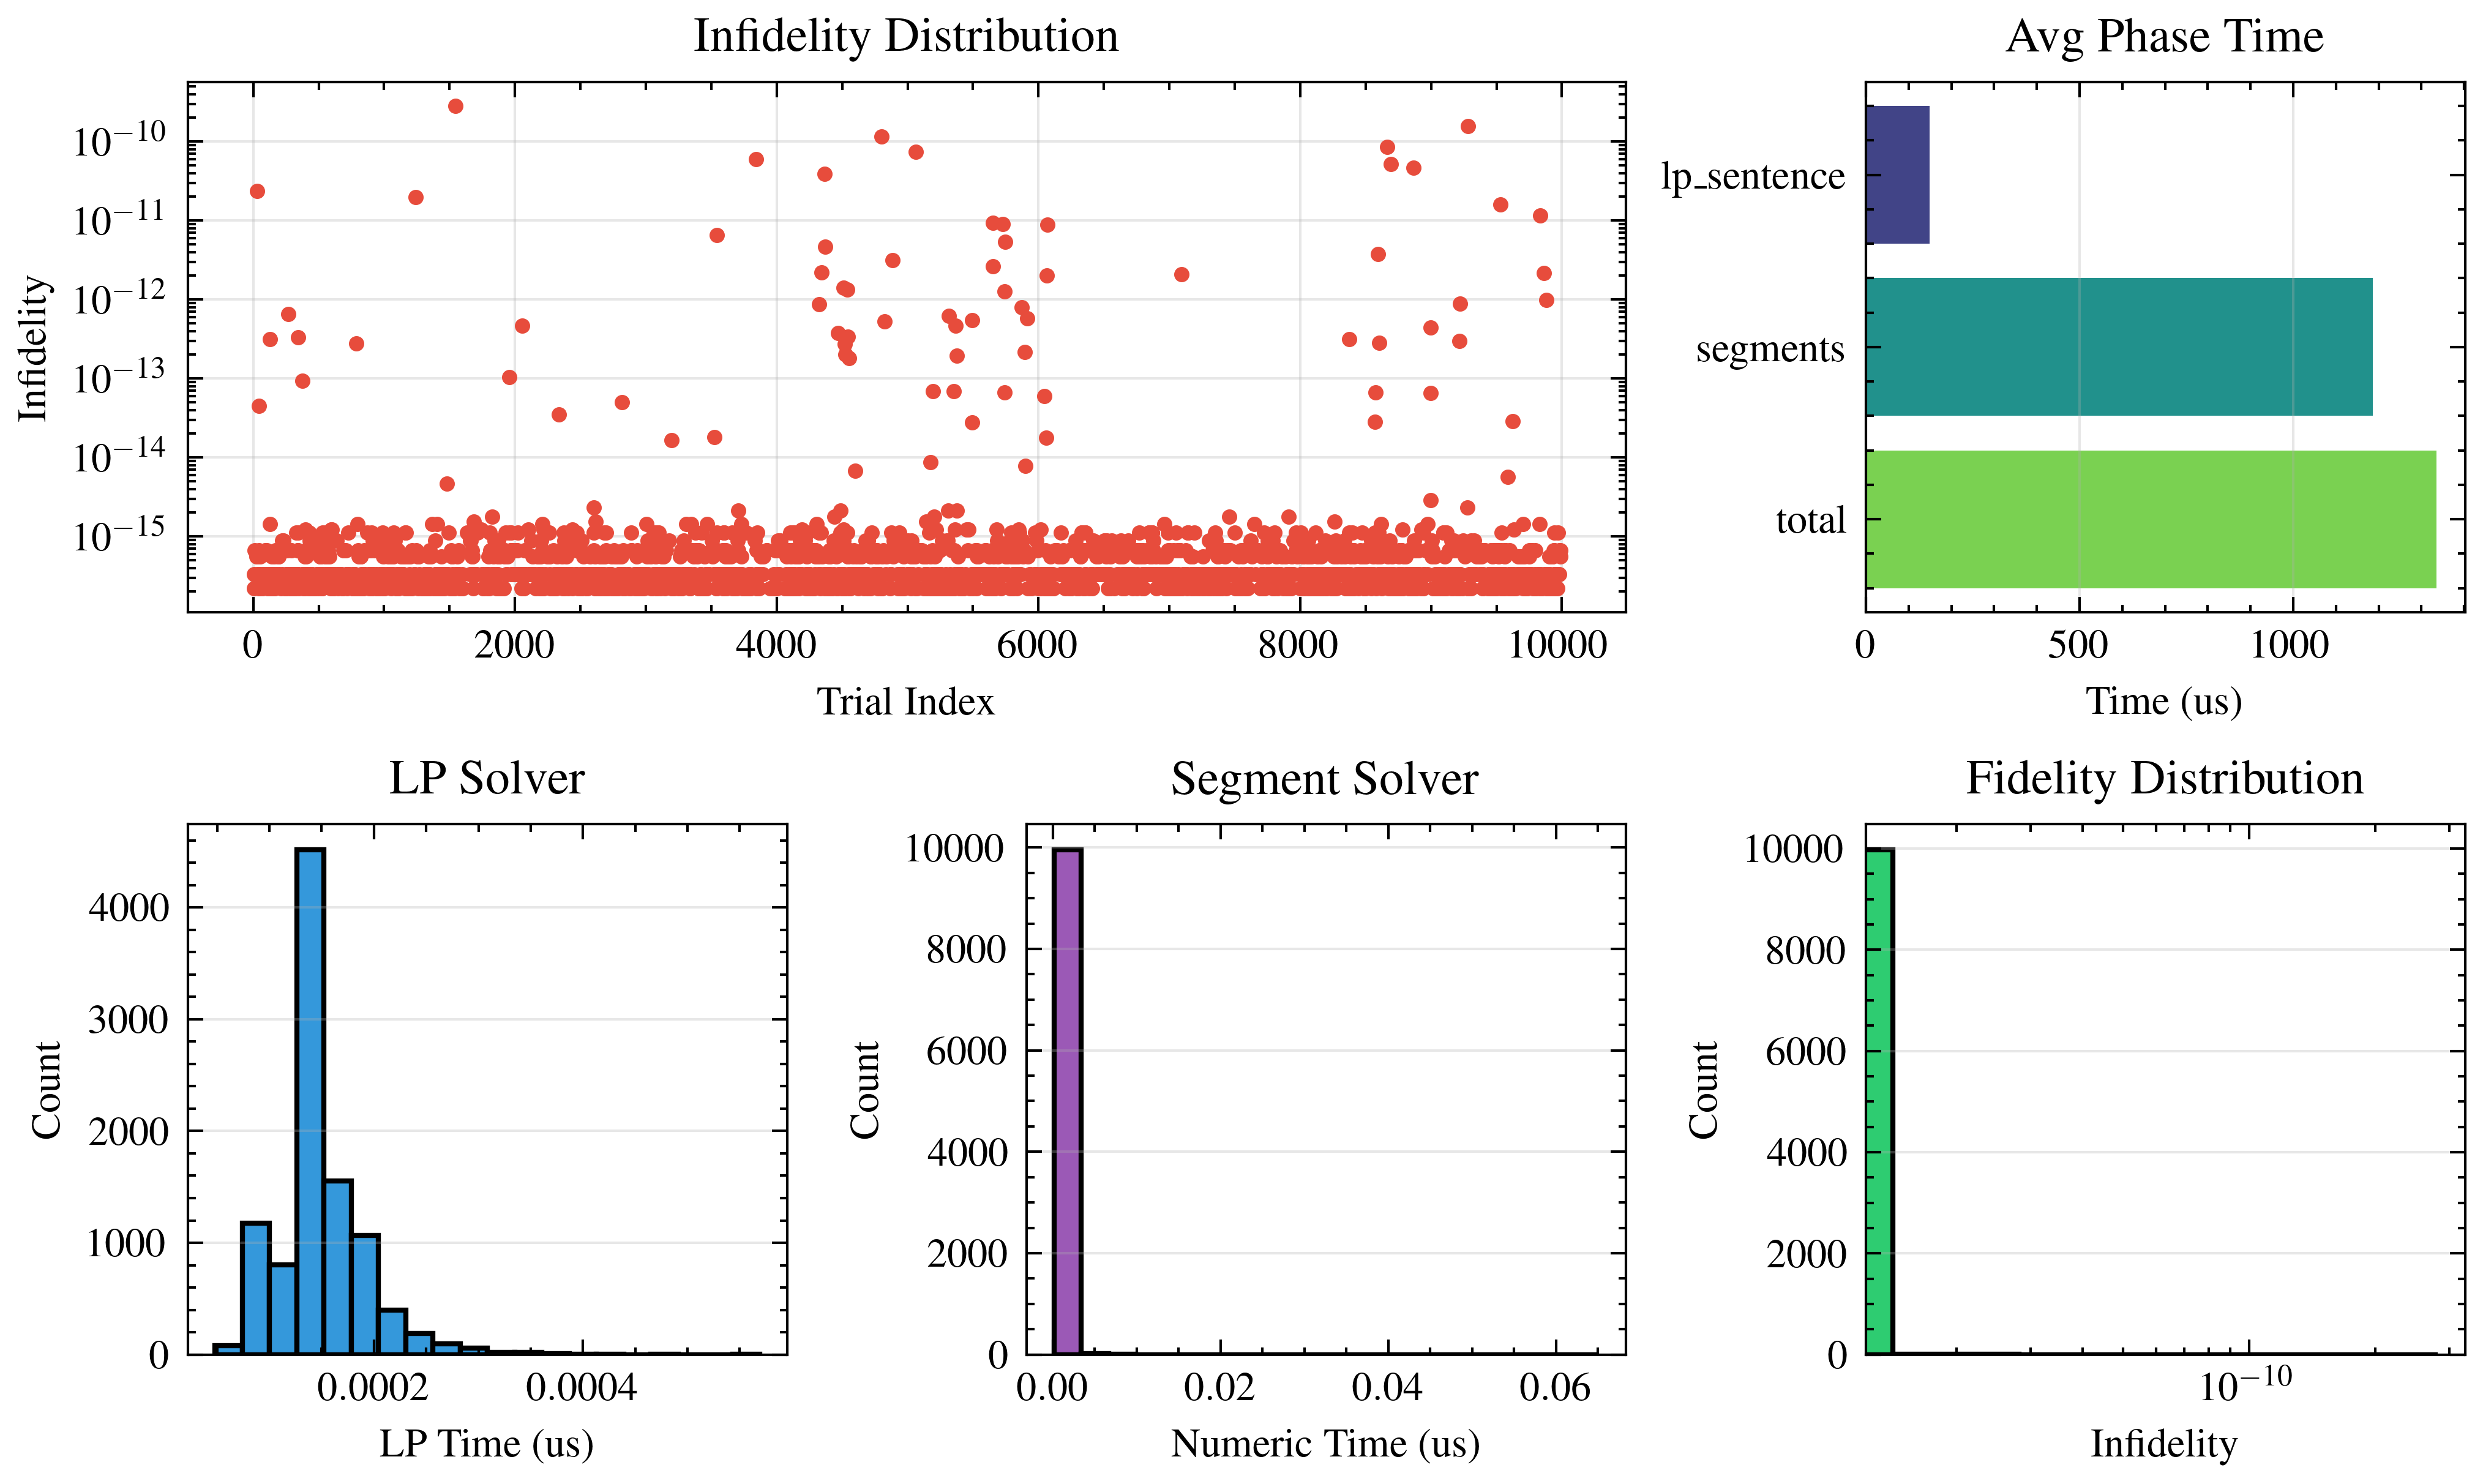

In [20]:
report_benchmark_results(fidelities, all_timings, decomposer, N, failures)

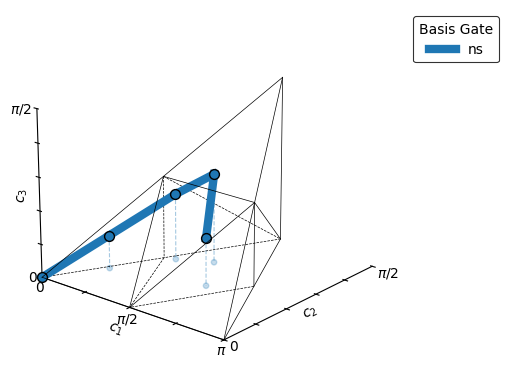

In [24]:
from IPython.display import display, clear_output
import time

fig_display = display(display_id=True)

for _i in range(50):
    clear_output(wait=True)
    r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
    fig = plot_decomposition(r.intermediates, r.sentence, isa)

    display(fig)
    plt.close(fig)
    time.sleep(0.15)  # 150ms delay